In [1]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from scipy.stats import normaltest
from scipy.stats import levene

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
df.head()

,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control


In [5]:
control_group = df[
    df['group'] == 'control'
]

In [6]:
test_group = df[
    df['group'] == 'test'
]

In [7]:
print("Control Mean Purchase:")
print(control_group['purchase'].mean())

print()

print("Test Mean Purchase:")
print(test_group['purchase'].mean())

Control Mean Purchase:
522.7931034482758

Test Mean Purchase:
521.2333333333333


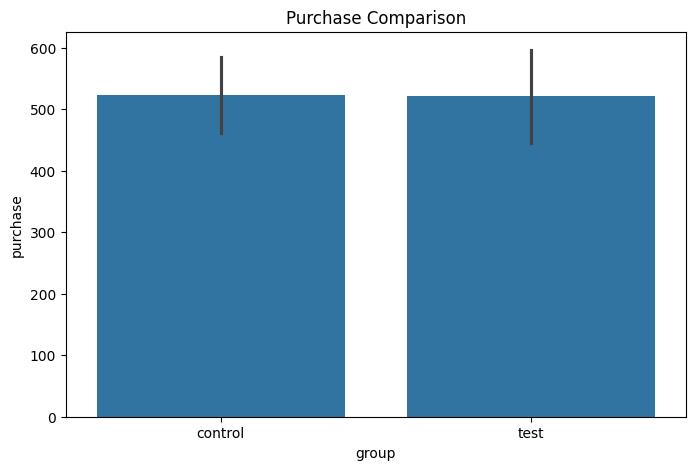

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='group',
    y='purchase',
    data=df
)

plt.title('Purchase Comparison')

plt.show()

In [9]:
stat, p = normaltest(
    control_group['purchase']
)

print("Control p-value:", p)

Control p-value: nan


In [10]:
stat, p = normaltest(
    test_group['purchase']
)

print("Test p-value:", p)

Test p-value: 0.005376352207858708


In [11]:
stat, p = levene(
    control_group['purchase'],
    test_group['purchase']
)

print("Levene p-value:", p)

Levene p-value: nan


In [12]:
t_stat, p_value = ttest_ind(
    control_group['purchase'],
    test_group['purchase'],
    equal_var=True
)

print("T-Statistic:", t_stat)

print("P-Value:", p_value)

T-Statistic: nan
P-Value: nan


In [13]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("There is a statistically significant difference.")
else:
    print("Fail to Reject Null Hypothesis")
    print("There is no statistically significant difference.")

Fail to Reject Null Hypothesis
There is no statistically significant difference.


In [14]:
mean_purchase = df['purchase'].mean()

std_purchase = df['purchase'].std()

n = len(df)

margin_error = 1.96 * (
    std_purchase / np.sqrt(n)
)

lower = mean_purchase - margin_error

upper = mean_purchase + margin_error

print("95% Confidence Interval:")
print(lower, upper)

95% Confidence Interval:
472.1587221525043 571.8412778474957


In [15]:
mean1 = control_group['purchase'].mean()

mean2 = test_group['purchase'].mean()

std1 = control_group['purchase'].std()

std2 = test_group['purchase'].std()

n1 = len(control_group)

n2 = len(test_group)

pooled_std = np.sqrt(
    (
        ((n1 - 1) * std1**2) +
        ((n2 - 1) * std2**2)
    ) / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 0.007859167874136621


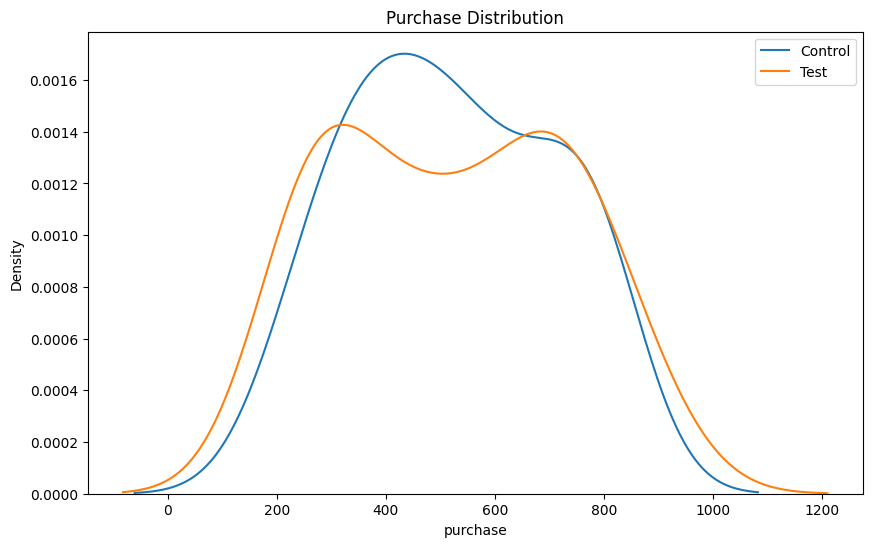

In [16]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    control_group['purchase'],
    label='Control'
)

sns.kdeplot(
    test_group['purchase'],
    label='Test'
)

plt.title('Purchase Distribution')

plt.legend()

plt.show()

In [17]:
print("========== A/B TEST SUMMARY ==========")

print()

print("Control Mean:",
      control_group['purchase'].mean())

print("Test Mean:",
      test_group['purchase'].mean())

print()

print("P-Value:", p_value)

print("Cohen's d:", cohens_d)

========== A/B TEST SUMMARY ==========

Control Mean: 522.7931034482758
Test Mean: 521.2333333333333

P-Value: nan
Cohen's d: 0.007859167874136621
